## Упражнения  

1. Выбрать и скачать один из наборов данных с сайта [timeseriesclassification](https://www.timeseriesclassification.com/dataset.php). 

    Подробнее о датасетах, их форматах, и как их скачивать - [Ноутбук](https://github.com/aeon-toolkit/aeon/blob/main/examples/datasets/data_loading.ipynb)

2.  Записать название выбранного датасета в таблицу. Помните - совпадений быть не должно. Каждый работает с уникальным датасетом. Этот датасет вам понадобиться в лабе 14 (aeon) и лабе 16 (tslean)

3. Проанализировать датасет

4. Найти шейплеты для классов в датесете

5. Провести классификацию на основе шейплетов.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyts.classification import LearningShapelets
from pyts.transformation import ShapeletTransform
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:

def load_ts_data(filepath):
    """Load time series data from .txt file (UCR/UEA format)"""
    data = []
    labels = []
    with open(filepath, 'r') as f:
        for line in f:
            values = line.strip().split()
            if len(values) > 1:
                labels.append(int(float(values[0])))
                data.append([float(v) for v in values[1:]])
    return np.array(data), np.array(labels)

In [3]:
print("=" * 60)
print("SHAPELET ANALYSIS - SYMBOLS DATASET")
print("=" * 60)

# 1. Load the dataset
print("\n1. Loading Symbols dataset...")
X_train, y_train = load_ts_data('Symbols/Symbols_TRAIN.txt')
X_test, y_test = load_ts_data('Symbols/Symbols_TEST.txt')

print(f"   Training samples: {X_train.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Time series length: {X_train.shape[1]}")
print(f"   Number of classes: {len(np.unique(y_train))}")
print(f"   Classes: {np.unique(y_train)}")

# 2. Dataset Analysis
print("\n2. Dataset Analysis:")
print("-" * 40)

# Class distribution
for cls in np.unique(y_train):
    count = np.sum(y_train == cls)
    print(f"   Class {int(cls)}: {count} training samples ({100*count/len(y_train):.1f}%)")

# Time series statistics
print(f"\n   Time series length: {X_train.shape[1]}")
print(f"   Value range: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"   Mean value: {X_train.mean():.3f}")
print(f"   Std deviation: {X_train.std():.3f}")

SHAPELET ANALYSIS - SYMBOLS DATASET

1. Loading Symbols dataset...
   Training samples: 25
   Test samples: 995
   Time series length: 398
   Number of classes: 6
   Classes: [1 2 3 4 5 6]

2. Dataset Analysis:
----------------------------------------
   Class 1: 8 training samples (32.0%)
   Class 2: 5 training samples (20.0%)
   Class 3: 3 training samples (12.0%)
   Class 4: 3 training samples (12.0%)
   Class 5: 3 training samples (12.0%)
   Class 6: 3 training samples (12.0%)

   Time series length: 398
   Value range: [-2.311, 2.205]
   Mean value: -0.000
   Std deviation: 0.999



3. Visualizing sample time series from each class...


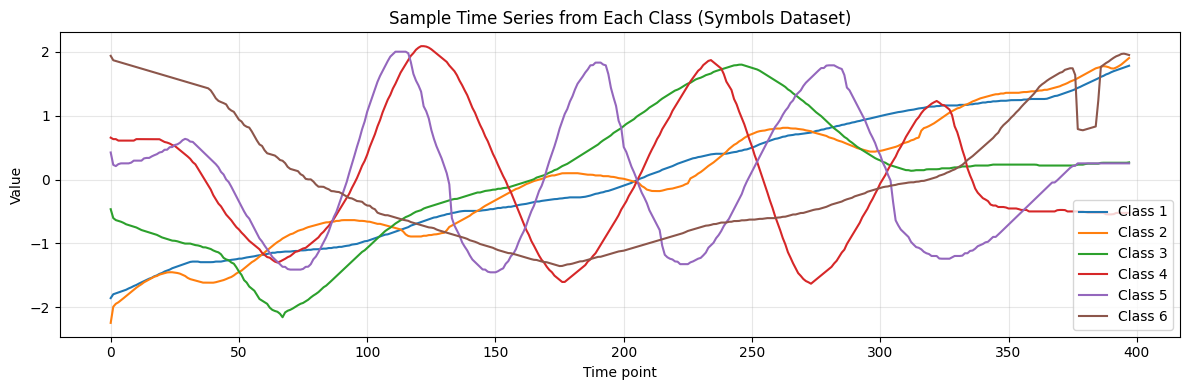

In [5]:
# 3. Visualize sample time series from each class
print("\n3. Visualizing sample time series from each class...")
plt.figure(figsize=(12, 4))
for i, cls in enumerate(np.unique(y_train)):
    idx = np.where(y_train == cls)[0][0]
    plt.plot(X_train[idx], label=f'Class {int(cls)}')
plt.xlabel('Time point')
plt.ylabel('Value')
plt.title('Sample Time Series from Each Class (Symbols Dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [6]:
# 4. Shapelet-based Classification using LearningShapelets
print("\n4. Learning Shapelets and Training Classifier...")
print("   This may take a moment...")

# LearningShapelets learns discriminative shapelets using gradient descent
# n_shapelets_per_size: number of shapelets to learn per size (can be int or float)
# min_shapelet_length: minimum shapelet length as a fraction of time series length
clf = LearningShapelets(
    n_shapelets_per_size=3,
    min_shapelet_length=0.1,
    max_iter=500,
    random_state=42,
    verbose=0
)

clf.fit(X_train, y_train)
print("   Classifier trained successfully!")


4. Learning Shapelets and Training Classifier...
   This may take a moment...
   Classifier trained successfully!



5. Visualizing learned shapelets...
   Found 9 shapelets
   Saved: learned_shapelets.png


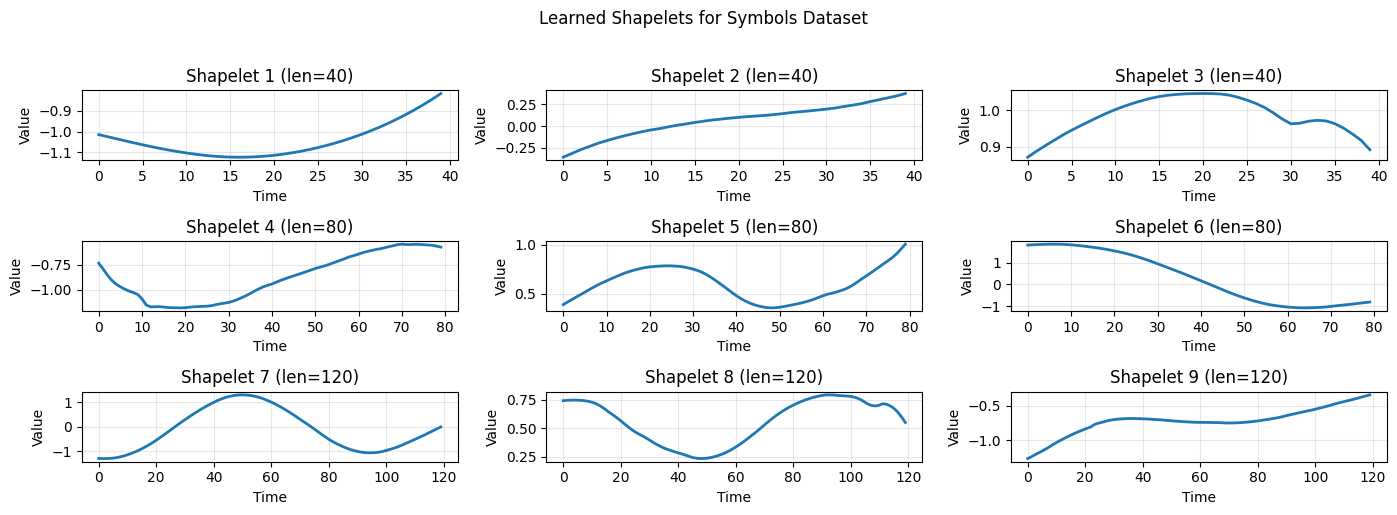

In [8]:
# 5. Extract and visualize learned shapelets
print("\n5. Visualizing learned shapelets...")

# Get the learned shapelets (shapelets_ is a 2D array: n_sizes x n_shapelets_per_size)
shapelets_array = clf.shapelets_
# Flatten the shapelets array to get individual shapelets
shapelets = []
for size_idx in range(shapelets_array.shape[0]):
    for s_idx in range(shapelets_array.shape[1]):
        shapelet = shapelets_array[size_idx, s_idx]
        if isinstance(shapelet, np.ndarray) and len(shapelet) > 0:
            shapelets.append(shapelet)

print(f"   Found {len(shapelets)} shapelets")

plt.figure(figsize=(14, 5))
for i, shapelet in enumerate(shapelets[:min(9, len(shapelets))]):
    plt.subplot(3, 3, i + 1)
    plt.plot(shapelet, linewidth=2)
    plt.title(f'Shapelet {i + 1} (len={len(shapelet)})')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.grid(True, alpha=0.3)
plt.suptitle('Learned Shapelets for Symbols Dataset', y=1.02)
plt.tight_layout()
print("   Saved: learned_shapelets.png")

In [9]:
# 6. Shapelet-based Classification Results
print("\n6. Shapelet-based Classification Results:")
print("-" * 40)

# Predict on test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n   Test Accuracy: {accuracy:.4f} ({100*accuracy:.2f}%)")

# Classification report
print("\n   Classification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=[f'Class {int(c)}' for c in np.unique(y_test)]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n   Confusion Matrix:")
print("   " + str(cm).replace('\n', '\n   '))


6. Shapelet-based Classification Results:
----------------------------------------

   Test Accuracy: 0.9085 (90.85%)

   Classification Report:
              precision    recall  f1-score   support

     Class 1       0.86      1.00      0.93       173
     Class 2       0.99      0.83      0.90       157
     Class 3       0.95      0.93      0.94       164
     Class 4       0.85      0.92      0.88       178
     Class 5       0.90      0.82      0.86       159
     Class 6       0.93      0.95      0.94       164

    accuracy                           0.91       995
   macro avg       0.91      0.91      0.91       995
weighted avg       0.91      0.91      0.91       995


   Confusion Matrix:
   [[173   0   0   0   0   0]
    [ 27 130   0   0   0   0]
    [  1   0 152   0   0  11]
    [  0   0   0 164  14   0]
    [  0   0   0  29 130   0]
    [  0   1   8   0   0 155]]


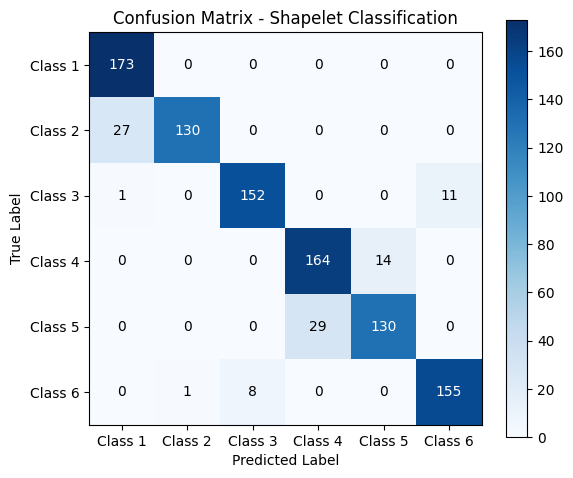

<Figure size 640x480 with 0 Axes>

In [11]:

# Visualize confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Shapelet Classification')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y_test)))
plt.xticks(tick_marks, [f'Class {int(c)}' for c in np.unique(y_test)])
plt.yticks(tick_marks, [f'Class {int(c)}' for c in np.unique(y_test)])

for i in range(len(np.unique(y_test))):
    for j in range(len(np.unique(y_test))):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


7. Visualizing Shapelet Matches on Test Samples...


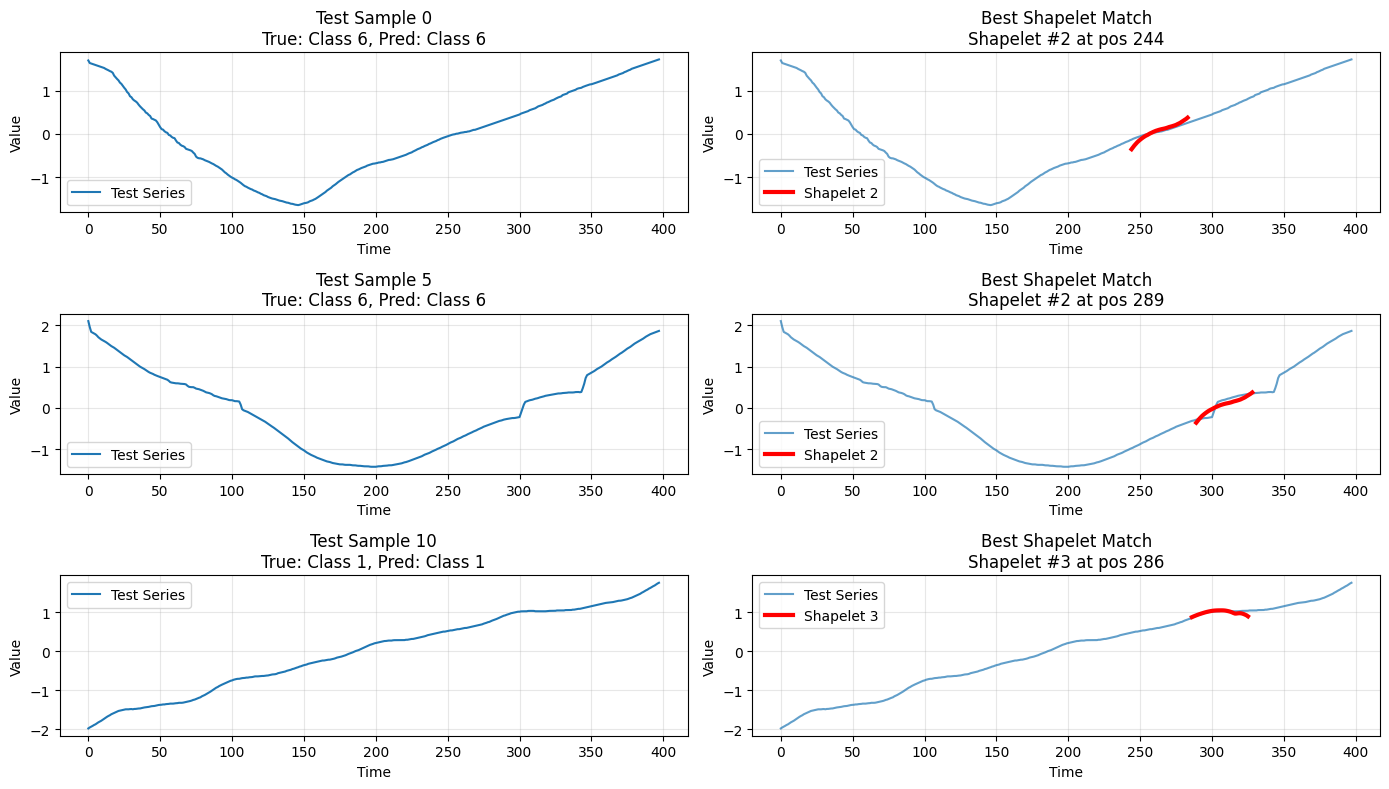

In [13]:
# 7. Visualize shapelet matches on sample series
print("\n7. Visualizing Shapelet Matches on Test Samples...")

sample_indices = [0, 5, 10]

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(14, 8))
if len(sample_indices) == 1:
    axes = axes.reshape(1, -1)

for idx, (sample_idx, ax_row) in enumerate(zip(sample_indices, axes)):
    ts = X_test[sample_idx]
    true_label = y_test[sample_idx]
    pred_label = y_pred[sample_idx]
    
    # Plot original time series
    ax_row[0].plot(ts, linewidth=1.5, label='Test Series')
    ax_row[0].set_title(f'Test Sample {sample_idx}\nTrue: Class {int(true_label)}, Pred: Class {int(pred_label)}')
    ax_row[0].set_xlabel('Time')
    ax_row[0].set_ylabel('Value')
    ax_row[0].legend()
    ax_row[0].grid(True, alpha=0.3)
    
    # Find best matching shapelet
    best_shapelet_idx = 0
    best_match_pos = 0
    best_distance = float('inf')
    
    for s_idx, shapelet in enumerate(shapelets):
        for pos in range(len(ts) - len(shapelet) + 1):
            segment = ts[pos:pos + len(shapelet)]
            distance = np.sum((segment - shapelet) ** 2)
            if distance < best_distance:
                best_distance = distance
                best_shapelet_idx = s_idx
                best_match_pos = pos
    
    # Plot test series with shapelet overlay
    ax_row[1].plot(ts, linewidth=1.5, label='Test Series', alpha=0.7)
    shapelet = shapelets[best_shapelet_idx]
    ax_row[1].plot(range(best_match_pos, best_match_pos + len(shapelet)), 
                   shapelet, 'r-', linewidth=3, label=f'Shapelet {best_shapelet_idx + 1}')
    ax_row[1].set_title(f'Best Shapelet Match\nShapelet #{best_shapelet_idx + 1} at pos {best_match_pos}')
    ax_row[1].set_xlabel('Time')
    ax_row[1].set_ylabel('Value')
    ax_row[1].legend()
    ax_row[1].grid(True, alpha=0.3)
plt.tight_layout()